# Current-Dependent Characterization

This example demonstrates how the behavior of measurement primitives like [CvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.CvJob) adapts depending on the potentiostat's operating mode. Specifically, we'll show that:

* In **potentiostatic** mode, the CV sweep controls voltage and the vertex values represent current turning points.
* In **galvanostatic** mode, the same CV sweep controls current and the vertex values represent voltage turning points.

Additionally, we'll demonstrate rapid impedance tracking on a diode operating at a constant current of 1 A. As the diode heats up, the forward voltage drops and the impedance rises, effects that can be captured in real time by measuring impedance at a single frequency with high repetition rate using [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob).

All measurements in this example were performed using the Zahner TestBox with the slide switch set to the **LoZ** position, which connects anti-parallel Schottky diodes to the potentiostat. The other switch position **HiZ** selects a high-impedance RC network. Note that the Schottky diodes are connected with a two-wire setup rather than a four-wire (Kelvin) connection, due to the physical design of the TestBox.

In [28]:
import matplotlib.pyplot as plt
from matplotlib.ticker import EngFormatter
from typing import Optional, List
import numpy as np
import zahner_link as zl


def plot_dataset_tiu(dataset: zl.DcDataset):
    """Plot voltage and current vs time from a dataset.

    This function creates a dual-axis plot showing voltage and current
    measurements over time from a DC dataset.
    """
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    (line1,) = ax1.plot(time, voltage, color="blue", label="Voltage")
    (line2,) = ax2.plot(time, current, color="red", label="Current")
    ax1.legend(handles=[line1, line2])

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Voltage")
    ax1.grid(True, "both")
    ax2.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax2.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Current")

    fig.set_size_inches(18, 10)
    plt.show()
    return


def plot_dataset_ui(dataset: zl.DcDataset):
    """Plot current vs voltage from a dataset.

    This function creates a standard current-voltage plot (I-V curve)
    from a DC dataset.
    """
    time = dataset.get_dc_track("time")
    voltage = dataset.get_dc_track("voltage")
    current = dataset.get_dc_track("current")

    fig, ax1 = plt.subplots()
    (line1,) = ax1.plot(voltage, current, color="orange")

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit="$A$"))
    ax1.set_xlabel("Voltage")
    ax1.set_ylabel("Current")
    ax1.grid(True, "both")

    fig.set_size_inches(18, 10)
    plt.show()
    return


def plot_dataset_tz(dataset: zl.EisDataset):
    """Plot voltage and impedance vs time from a dataset.

    This function creates a dual-axis plot showing voltage and current
    measurements over time from a DC dataset.
    """
    impedance = dataset.get_impedance_data().get_calculated_complex_impedance_track()
    time = dataset.get_times()
    voltage = dataset.get_path_data("voltage").get_dc_track()

    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    (line1,) = ax1.plot(time, np.abs(impedance), color="green", label="Impedance")
    (line2,) = ax2.plot(time, voltage, color="blue", label="Voltage")
    ax1.legend(handles=[line1, line2], loc="center right")

    ax1.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax1.yaxis.set_major_formatter(EngFormatter(unit=r"$\Omega$"))
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Impedance")
    ax1.grid(True, "both")
    ax2.xaxis.set_major_formatter(EngFormatter(unit="$s$"))
    ax2.yaxis.set_major_formatter(EngFormatter(unit="$V$"))
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Voltage")

    fig.set_size_inches(18, 10)
    plt.show()
    return

## Connecting to the IM7

We create a [ZahnerLinkExc](https://doc.zahner.de/im7/apis/zahner_link/python/pages/fundamental.html#zahner_link.ZahnerLinkExc) object and connect to the IM7 using its IP address and port.

In [29]:
link = zl.ZahnerLinkExc("169.254.17.168", "1994")
error: zl.ErrorObject = link.connect()

if not error:
    print("connected successfully")
else:
    print(
        f"failed to connect, status: {error.get_error_code_enum()}, message: {error.get_message_formatted()}"
    )

connected successfully


## Potentiostatic CV

First, we switch on the potentiostat in **potentiostatic** mode using [SwitchOnJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/control.html#zahner_link.control.SwitchOnJob). In this mode, the [CvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.CvJob) parameters `first_vertex` and `second_vertex` define **voltage** turning points, and the sweep controls the applied voltage.

The CV sweeps from 0 V → +0.5 V → −0.5 V → 0 V with a scan rate of 20 mV/s while current and voltage are measured.  
The current limits for reversing the scan before the voltage vertexes are set to +- 1 A.

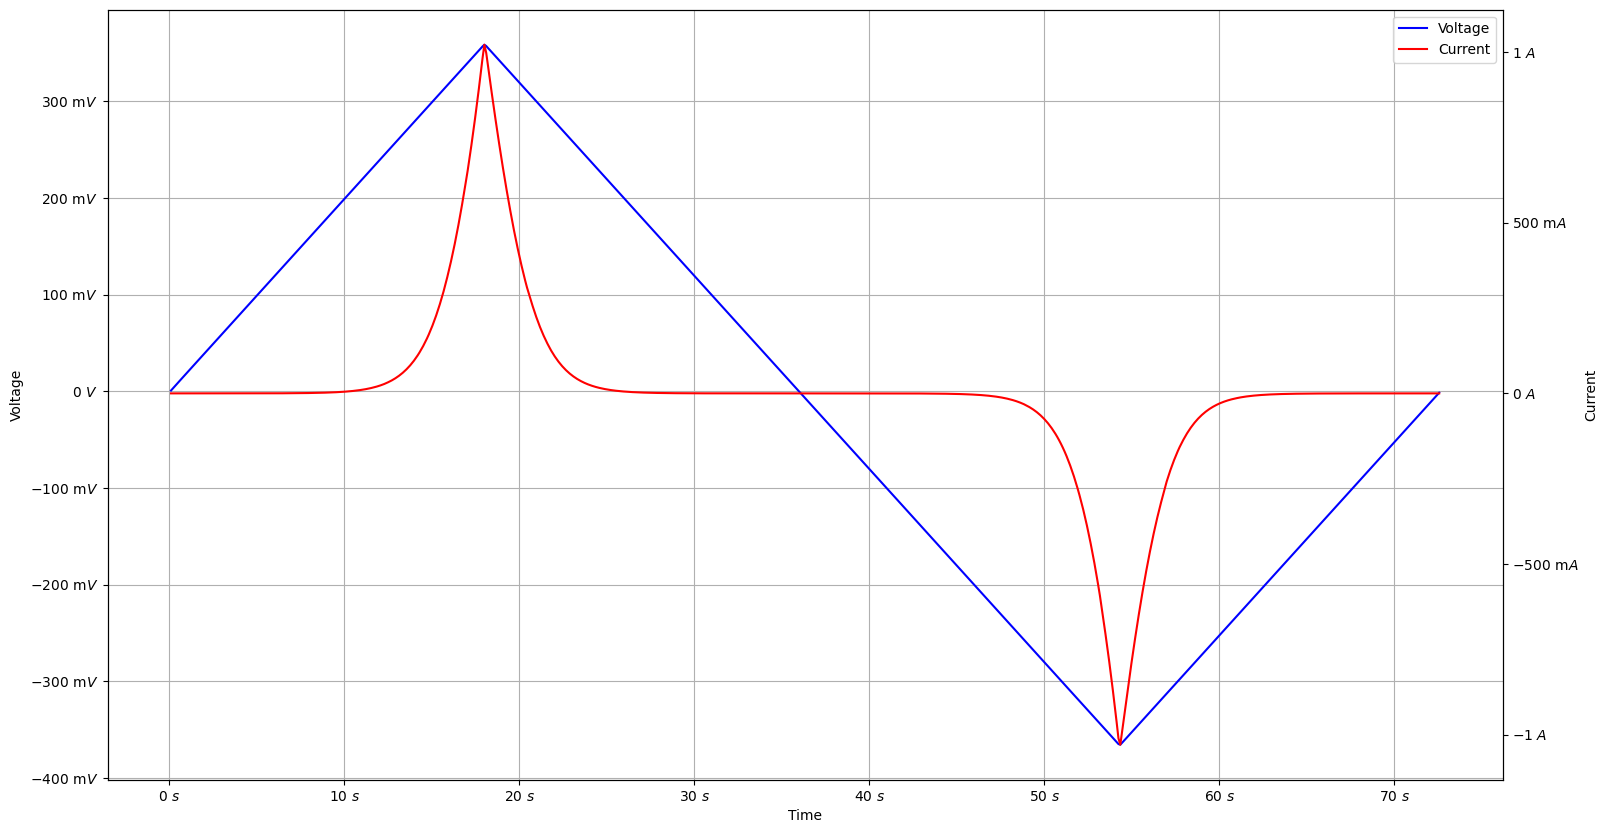

In [30]:
switch_on_job = zl.control.SwitchOnJob(
    potentiostat="MAIN:1:POT",
    coupling=zl.PotentiostatCoupling.POTENTIOSTATIC,
    bias=0,
    voltage_range_index=0,
    compliance_range_index=0,
)
switch_off_job = zl.control.SwitchOffJob(potentiostat="MAIN:1:POT")

link.do_job(switch_on_job)

cv_job = zl.meas.CvJob(
    start_value=0,
    first_vertex=0.5,
    second_vertex=-0.5,
    end_value=0,
    scan_rate=0.02,
    output_data_rate=10,
    num_cycles=0.5,
    autorange=True,
    current_range=1,
    turn_limit_check=True,
    upper_turn_boundary=1,
    lower_turn_boundary=-1,
    step_height=0,
    ir_drop=0,
)
link.do_job(cv_job)
link.do_job(switch_off_job)
cv_job_data = link.get_job_result_data(cv_job)

plot_dataset_tiu(cv_job_data)

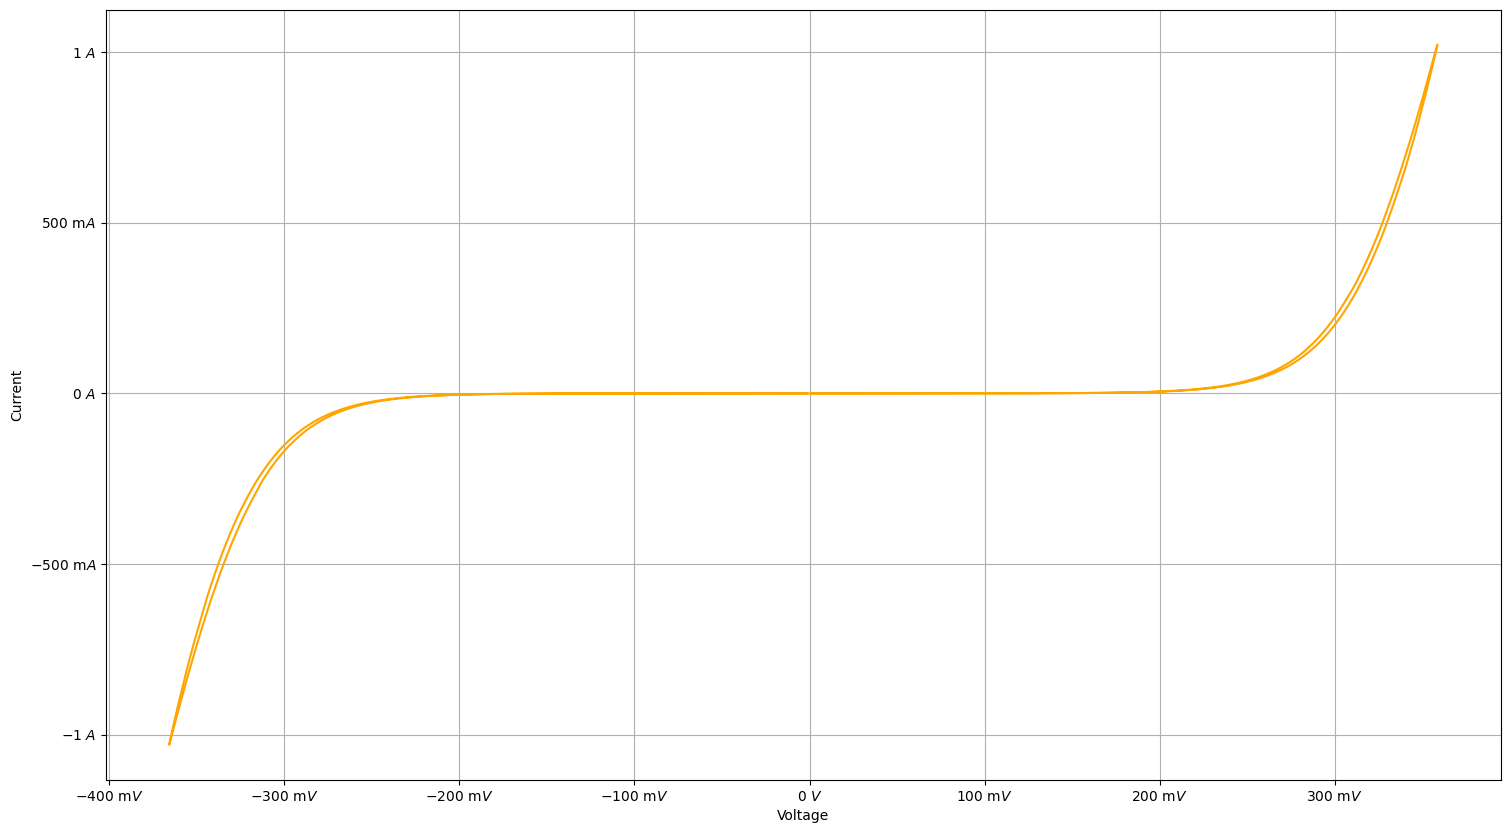

In [31]:
plot_dataset_ui(cv_job_data)

## Galvanostatic CV

Now we switch the coupling to **galvanostatic** mode.

To do this, we simply reuse the existing switch-on job and change its coupling parameter to galvanostatic. Alternatively, you could create an entirely new switch-on job.

In [32]:
switch_on_job.parameters.coupling = zl.PotentiostatCoupling.GALVANOSTATIC
link.do_job(switch_on_job)

The exact same [CvJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.CvJob) primitive now interprets `first_vertex` and `second_vertex` as **current** turning points. The sweep controls the applied current while the voltage is measured as the response signal.

The CV sweeps from 0 A → +1 A → −1 A → 0 A with a scan rate of 100 mA/s while current and voltage are measured.  
The voltage limits for reversing the scan before the current vertexes are set to +- 1 V.  
But these voltage limits will not be reached.

This demonstrates a key concept of the zahner_link API:

**The measurement primitives adapt their behavior based on the potentiostat's operating mode, so the same job type can be used for both potentiostatic and galvanostatic experiments.**

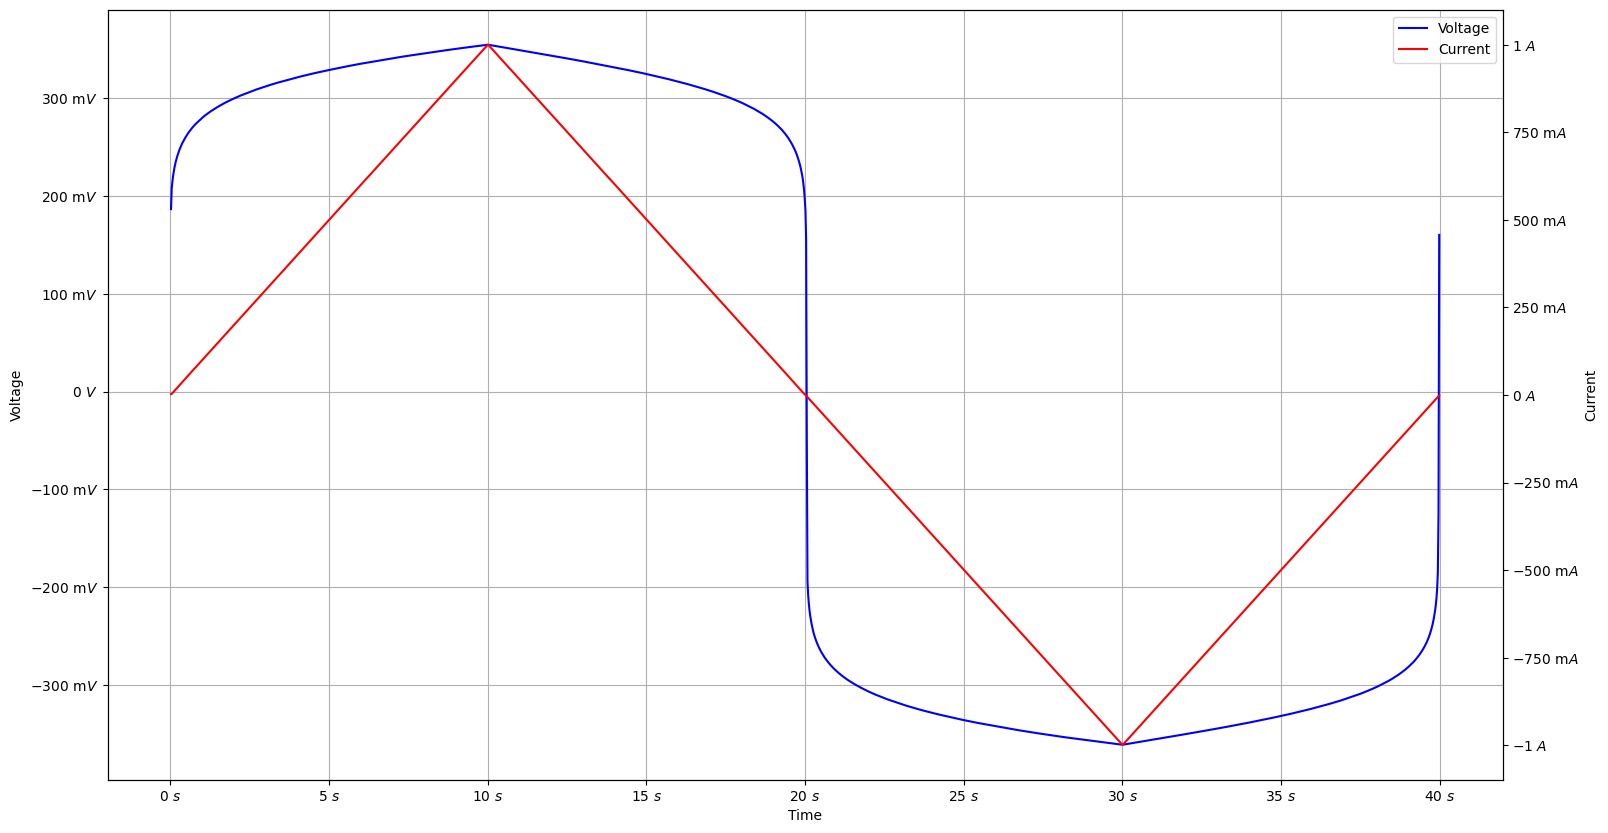

In [33]:
cv_job_galvanostatic = zl.meas.CvJob(
    start_value=0,
    first_vertex=1,
    second_vertex=-1,
    end_value=0,
    scan_rate=0.1,
    output_data_rate=50,
    num_cycles=0.5,
    autorange=True,
    current_range=1,
    turn_limit_check=True,
    upper_turn_boundary=1,
    lower_turn_boundary=-1,
    step_height=0,
    ir_drop=0,
)
link.do_job(cv_job_galvanostatic)
link.do_job(switch_off_job)
cv_job_galvanostatic_data = link.get_job_result_data(cv_job_galvanostatic)

plot_dataset_tiu(cv_job_galvanostatic_data)

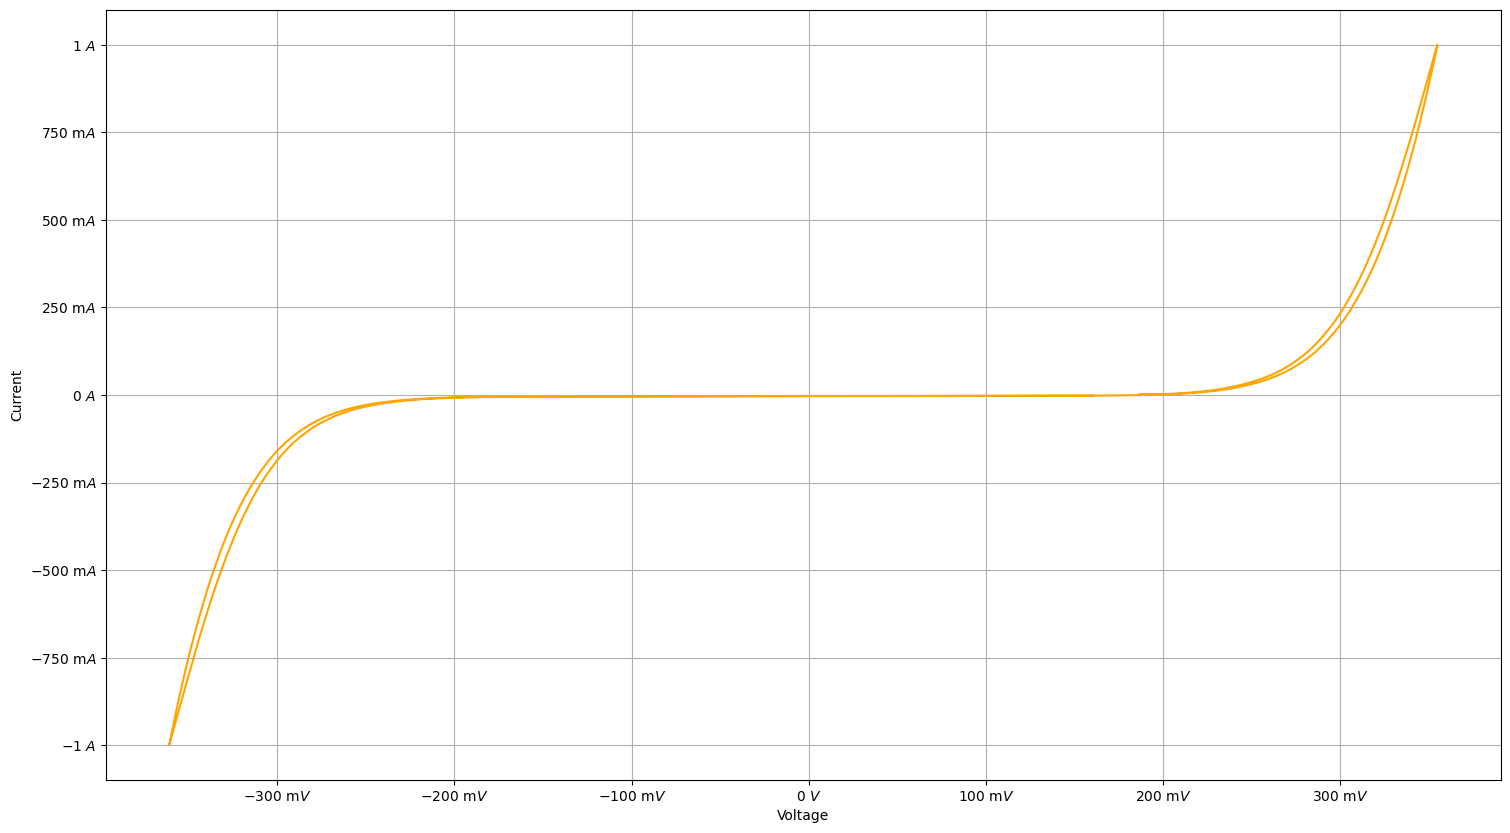

In [34]:
plot_dataset_ui(cv_job_galvanostatic_data)

## Real-Time Impedance Tracking on a Heating Diode

To showcase the speed of impedance measurements, we measure a diode at a constant galvanostatic bias of 1 A. 

As current flows through the diode, it heats up over time. This thermal change has two observable effects:

* **forward voltage decreases** as the junction temperature rises (typical temperature coefficient of approximately −2 mV/K)
* **impedance increases** because the differential resistance of the diode changes with temperature

We use [EisFrequencyTableJob](https://doc.zahner.de/im7/apis/zahner_link/python/pages/meas.html#zahner_link.meas.EisFrequencyTableJob) with 200 repeated measurements at 1 kHz to capture these dynamics in real time. Each measurement point takes only a fraction of a second, allowing us to track the thermal transient with high time resolution.  
The `meas_duration` for impedance measurement is set to 0.1 s. If the pre wave is neglected, approximately ten impedance measurement points per second are obtained.

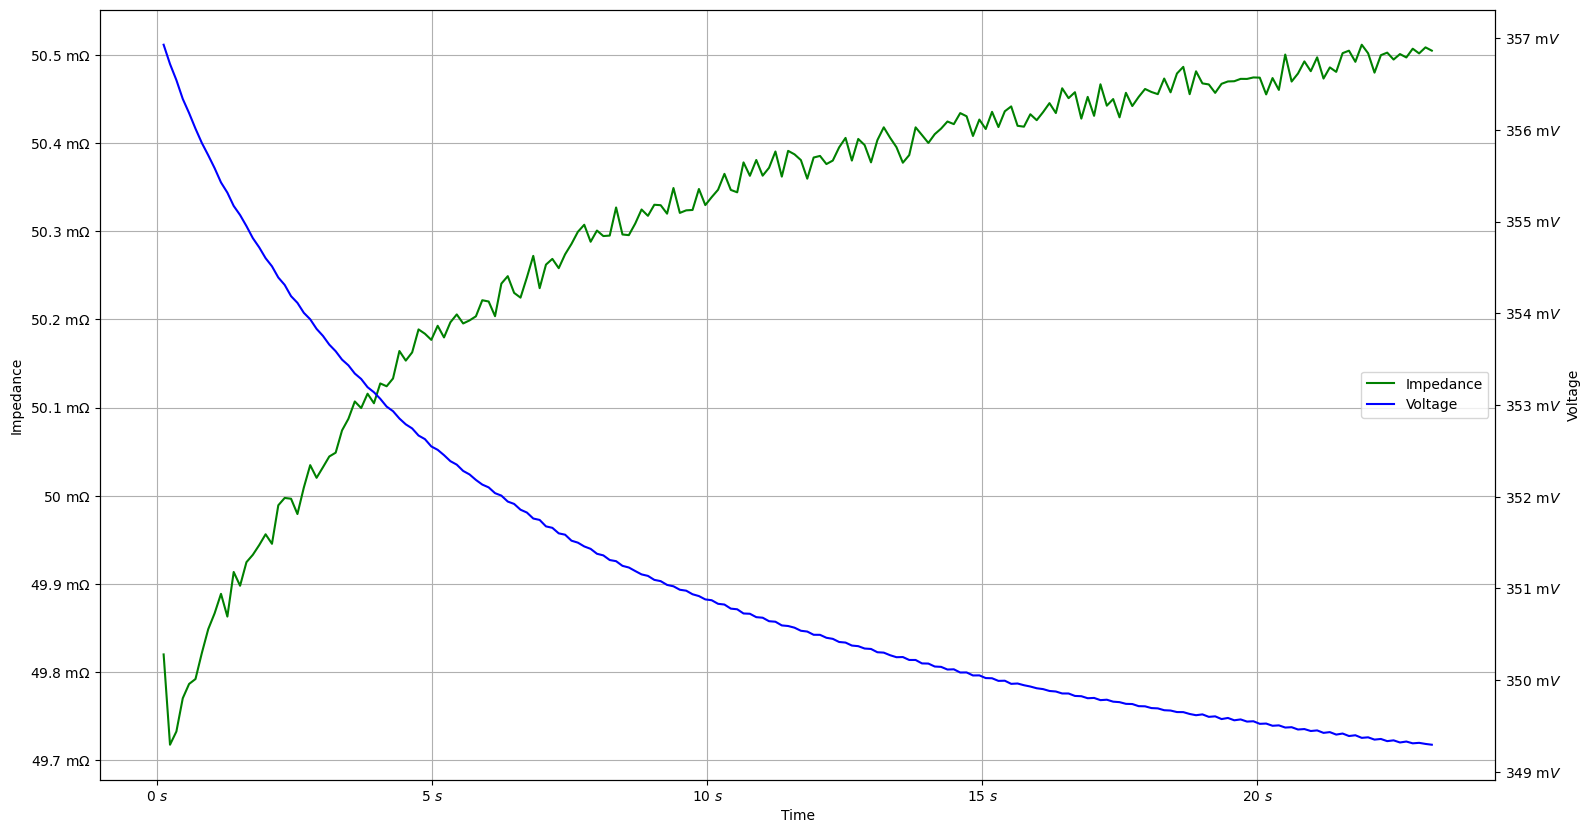

In [35]:
frequencies_to_measure = [1e3 for _ in range(200)]
bias = 1.0
eis_dict_table_job = zl.meas.EisFrequencyTableJob(
    {
        "bias": bias,
        "spectrum": [
            {
                "frequency": freq,
                "amplitude": 0.1,
                "pre_duration": 0.0,
                "pre_waves": 1,
                "meas_duration": 0.1,
                "meas_waves": 1,
            }
            for freq in frequencies_to_measure
        ],
    }
)
switch_on_job.parameters.bias = bias
link.do_job(switch_on_job)
link.do_job(eis_dict_table_job)
link.do_job(switch_off_job)
eis_dict_table_data = link.get_job_result_data(eis_dict_table_job)

xml_measurement = zl.xml.Measurement(eis_dict_table_data)
exporter = zl.xml.ZXmlExporter()
exporter.set_compact_xml(False)
exporter.save_as_file_standalone(xml_measurement, "diode_fast_single_freq_eis.zmx")

plot_dataset_tz(eis_dict_table_data)

## Disconnect

Finally, we disconnect from the IM7. The collected measurement data remains available in the job objects even after disconnecting.

In [36]:
link.disconnect()